In [1]:
# %% [markdown]
# # Plot per-variable scores by backend LLM
#
# This notebook supports JSON files where metric labels look like:
#
# - `ALL.f1`
# - `ALL.precision`
# - `ALL.recall`
# - `habitat.f1`
# - `habitat.precision`
# - `ecosystem_type.category.f1`
#
# The last suffix is interpreted as the metric.
# Everything before the final dot is interpreted as the variable.

import json

# %%
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np

# Optional IEEE/science style
try:
    import scienceplots  # noqa: F401

    plt.style.use(["science", "ieee", "no-latex"])
except Exception:
    print("scienceplots not available; using current matplotlib style.")

scienceplots not available; using current matplotlib style.


In [2]:
# %% [markdown]
# ## Configuration

# %%
JSON_PATH = Path(
    "../data/prediction_results/logs/525_faktencheck_core_bestconfig_testset/figure_data/faktencheck_core_f1_micro_flat-ALL-data.json"
)
SCHEMA = "Faktencheck Core"

OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FORMATS = ["png", "pdf"]

# If None, all metrics found in the JSON are plotted.
# Otherwise, use e.g. ["f1", "precision", "recall"]
METRICS_TO_INCLUDE = None
# METRICS_TO_INCLUDE = ["f1", "precision", "recall"]

# If None, all variables found in the JSON are plotted.
# Otherwise, use e.g. ["ALL", "AVG", "habitat"]
VARIABLES_TO_INCLUDE = None
# VARIABLES_TO_INCLUDE = ["ALL", "AVG", "biodiversity_level", "habitat"]

# Error bars:
# "std" = standard deviation
# "sem" = standard error of the mean
ERRORBAR = "std"

# IEEE single-column figure size
IEEE_ONE_COLUMN_WIDTH_IN = 5  # 3.5
FIG_HEIGHT_IN = 5.4  # 2.7

BAR_WIDTH = 0.55

# Sort model bars by one reference variable and metric.
# Set to None to keep JSON order.
SORT_BY = {
    "variable": "ALL",
    "metric": "f1",
}

# If True, each plot is sorted by its own metric values.
# If False, all plots use the same model order.
SORT_EACH_PLOT_INDIVIDUALLY = False

PRETTY_METRIC = {
    "f1": "F1",
    "precision": "Precision",
    "recall": "Recall",
    "support": "Support",
}

PRETTY_LLM = {
    "gpt_oss_20b": "GPT OSS 20B",
    "mistral_small_3_24b": "Mistral Small 3 24B",
    "gemma3_27b": "Gemma 3 27B",
    "qwen3_30b": "Qwen 3 30B",
    "gpt_5": "GPT-5",
}

PRETTY_VARIABLE = {
    "ALL": "Micro average",
    "AVG": "Macro average",
    "biodiversity_level": "Biodiversity level",
    "ecosystem_type.category": "Ecosystem type - category",
    "ecosystem_type.term": "Ecosystem type - term",
    "habitat": "Habitat",
    "taxa.species_group": "Taxa - species group",
}

In [3]:
# %% [markdown]
# ## Helper functions


# %%
def clean_category_label(category: str) -> str:
    """
    Convert e.g.
    prediction.extractor/llm=gpt_oss_20b_in_process
    to
    GPT OSS 20B
    """
    match = re.search(r"llm=([^/]+)", category)
    label = match.group(1) if match else category

    if label.endswith("_in_process"):
        label = label[: -len("_in_process")]

    return PRETTY_LLM.get(label, label.replace("_", " ").title())


def short_model_label(label: str) -> str:
    """
    Shorten labels for IEEE single-column plots.
    """
    replacements = {
        "GPT OSS 20B": "GPT OSS\n20B",
        "Mistral Small 3 24B": "Mistral\nSmall 3",
        "Gemma 3 27B": "Gemma 3\n27B",
        "Qwen 3 30B": "Qwen 3\n30B",
        "GPT-5": "GPT-5",
    }
    return replacements.get(label, label)


def pretty_variable_name(variable: str) -> str:
    return PRETTY_VARIABLE.get(variable, variable.replace("_", " "))


def pretty_metric_name(metric: str) -> str:
    return PRETTY_METRIC.get(metric, metric.replace("_", " ").title())


def safe_filename(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9._-]+", "_", text)
    text = text.replace(".", "_")
    return text


def mean_and_error(samples, errorbar: str = "std"):
    samples = np.asarray(samples, dtype=float)

    if len(samples) == 0:
        raise ValueError("Found a point with an empty `samples` list.")

    mean = float(np.mean(samples))

    if len(samples) == 1:
        return mean, 0.0, 1

    std = float(np.std(samples, ddof=1))

    if errorbar == "std":
        err = std
    elif errorbar == "sem":
        err = std / np.sqrt(len(samples))
    else:
        raise ValueError(f"Unknown errorbar type: {errorbar}")

    return mean, err, len(samples)


def split_metric_label(metric_label: str):
    """
    Split metric labels of the form:

        variable.metric

    where variable itself may contain dots.

    Examples
    --------
    ALL.f1 -> variable='ALL', metric='f1'
    habitat.precision -> variable='habitat', metric='precision'
    ecosystem_type.category.f1 -> variable='ecosystem_type.category', metric='f1'
    """
    if "." not in metric_label:
        raise ValueError(
            f"Expected metric label of form '<variable>.<metric>', got: {metric_label}"
        )

    variable, metric = metric_label.rsplit(".", 1)
    return variable, metric

In [4]:
# %% [markdown]
# ## Load scores


# %%
def load_variable_metric_scores(
    json_path: Path,
    metrics_to_include=None,
    variables_to_include=None,
    errorbar: str = "std",
):
    with json_path.open("r", encoding="utf-8") as f:
        obj = json.load(f)

    # stats[metric][variable][category] = dict(mean=..., err=..., n=...)
    stats = {}
    metric_labels = {}

    first_plot = None

    for plot in obj["plots"]:
        metric_label = plot["metadata"]["metric_label"]
        variable, metric = split_metric_label(metric_label)

        if metrics_to_include is not None and metric not in metrics_to_include:
            continue

        if variables_to_include is not None and variable not in variables_to_include:
            continue

        if first_plot is None:
            first_plot = plot

        stats.setdefault(metric, {})
        stats[metric].setdefault(variable, {})
        metric_labels[(metric, variable)] = metric_label

        for point in plot["data"]["points"]:
            category = point["category"]
            samples = point["samples"]

            mean, err, n = mean_and_error(samples, errorbar=errorbar)

            stats[metric][variable][category] = {
                "mean": mean,
                "err": err,
                "n": n,
                "samples": samples,
            }

    if first_plot is None:
        raise ValueError("No matching plots found in JSON.")

    # Use first matching plot to define the default model order.
    categories = [point["category"] for point in first_plot["data"]["points"]]

    # Check category consistency.
    for metric, variable_dict in stats.items():
        for variable, category_dict in variable_dict.items():
            missing_categories = [
                category for category in categories if category not in category_dict
            ]

            if missing_categories:
                raise ValueError(
                    f"Metric={metric!r}, variable={variable!r} "
                    f"is missing categories: {missing_categories}"
                )

    return categories, stats, metric_labels


categories, stats, metric_labels = load_variable_metric_scores(
    JSON_PATH,
    metrics_to_include=METRICS_TO_INCLUDE,
    variables_to_include=VARIABLES_TO_INCLUDE,
    errorbar=ERRORBAR,
)

metrics = list(stats.keys())

# Union of variables across all metrics
variables = sorted({variable for metric in stats for variable in stats[metric]})

print("Loaded metrics:")
for metric in metrics:
    print(f"  {metric}")

print("\nLoaded variables:")
for variable in variables:
    print(f"  {variable}")

print("\nModels:")
for category in categories:
    print(f"  {clean_category_label(category)}")

Loaded metrics:
  f1
  precision
  recall
  support

Loaded variables:
  ALL

Models:
  GPT OSS 20B
  Mistral Small 3 24B
  Gemma 3 27B
  Qwen 3 30B


In [5]:
# %% [markdown]
# ## Sort models

# %%
if SORT_BY is not None:
    sort_variable = SORT_BY["variable"]
    sort_metric = SORT_BY["metric"]

    if sort_metric not in stats:
        raise ValueError(
            f"Sort metric {sort_metric!r} not found. " f"Available metrics: {list(stats.keys())}"
        )

    if sort_variable not in stats[sort_metric]:
        raise ValueError(
            f"Sort variable {sort_variable!r} not found for metric {sort_metric!r}. "
            f"Available variables for {sort_metric!r}: {list(stats[sort_metric].keys())}"
        )

    categories = sorted(
        categories,
        key=lambda category: stats[sort_metric][sort_variable][category]["mean"],
        reverse=True,
    )

labels = [clean_category_label(c) for c in categories]
plot_labels = [short_model_label(label) for label in labels]

print("Model order:")
for category, label in zip(categories, labels):
    if SORT_BY is not None:
        print(
            f"  {label}: "
            f"{stats[sort_metric][sort_variable][category]['mean']:.4f} "
            f"({sort_variable}.{sort_metric})"
        )
    else:
        print(f"  {label}")

Model order:
  GPT OSS 20B: 0.5038 (ALL.f1)
  Qwen 3 30B: 0.5016 (ALL.f1)
  Gemma 3 27B: 0.4281 (ALL.f1)
  Mistral Small 3 24B: 0.4277 (ALL.f1)


In [6]:
# %% [markdown]
# ## Color scheme

# %%
# Colorblind-friendly Okabe-Ito-inspired palette
MODEL_COLORS = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
]

model_colors = {
    category: MODEL_COLORS[i % len(MODEL_COLORS)] for i, category in enumerate(categories)
}

In [7]:
# %% [markdown]
# ## Plot function


# %%
def plot_variable_metric(metric: str, variable: str, output_paths):
    """
    Create and save one bar plot for one variable and one metric.

    Example
    -------
    plot_variable_metric(
        metric="f1",
        variable="habitat",
        output_paths=[
            Path("plots/habitat_f1.png"),
            Path("plots/habitat_f1.pdf"),
        ],
    )
    """
    if metric not in stats:
        raise ValueError(f"Unknown metric: {metric}")

    if variable not in stats[metric]:
        raise ValueError(f"Unknown variable {variable!r} for metric {metric!r}")

    if SORT_EACH_PLOT_INDIVIDUALLY:
        plot_categories = sorted(
            categories,
            key=lambda category: stats[metric][variable][category]["mean"],
            reverse=True,
        )
    else:
        plot_categories = list(categories)

    plot_labels_local = [
        clean_category_label(category)
        # short_model_label(clean_category_label(category))
        for category in plot_categories
    ]

    x = np.arange(len(plot_categories))

    means = np.array([stats[metric][variable][category]["mean"] for category in plot_categories])

    errs = np.array([stats[metric][variable][category]["err"] for category in plot_categories])

    ns = np.array([stats[metric][variable][category]["n"] for category in plot_categories])

    colors = [model_colors[category] for category in plot_categories]

    fig, ax = plt.subplots(figsize=(IEEE_ONE_COLUMN_WIDTH_IN, FIG_HEIGHT_IN))

    bars = ax.bar(
        x,
        means,
        width=BAR_WIDTH,
        color=colors,
        edgecolor="black",
        linewidth=0.6,
    )

    # Add error bars only for multi-run experiments.
    for xi, yi, err, n in zip(x, means, errs, ns):
        if n > 1:
            ax.errorbar(
                xi,
                yi,
                yerr=err,
                fmt="none",
                ecolor="black",
                elinewidth=0.8,
                capsize=8.5,
                capthick=0.8,
            )

    # Print scores on top of all bars with 3 significant digits.
    for bar, val, err, n in zip(bars, means, errs, ns):
        y = val + (err if n > 1 else 0.0) + 0.012
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y,
            f"{val:.3g}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    title = f"{pretty_variable_name(variable)} {pretty_metric_name(metric)} by backend LLM on the {SCHEMA} schema"

    ax.set_title(
        title,
        fontsize=10,
        fontweight="bold",
        pad=10,
    )

    ax.set_ylabel(pretty_metric_name(metric), fontsize=10)

    ax.set_xticks(x)
    ax.set_xticklabels(
        plot_labels_local,
        rotation=45,
        ha="center",
        fontsize=10,
    )

    ax.tick_params(axis="y", labelsize=10)

    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)

    max_y = float(np.max(means + np.where(ns > 1, errs, 0.0)))

    ax.set_xlim(-0.4, len(plot_categories) - 0.6)
    # Most metrics are 0--1. Support may not be.
    if metric.lower() == "support":
        ax.set_ylim(0, max_y * 1.15)
    else:
        # ax.set_ylim(0, min(1.05, max_y + 0.10))
        ax.set_ylim(0, 1.05)  # min(1.05, max_y + 0.10))

    fig.tight_layout(pad=0.4)

    for output_path in output_paths:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)

        fig.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )

        print(f"Saved {variable}.{metric} plot to: " f"{output_path.resolve()}")

    plt.show()

    return fig, ax

Saved ALL.f1 plot to: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm/notebooks/plots/all_f1.png
Saved ALL.f1 plot to: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm/notebooks/plots/all_f1.pdf


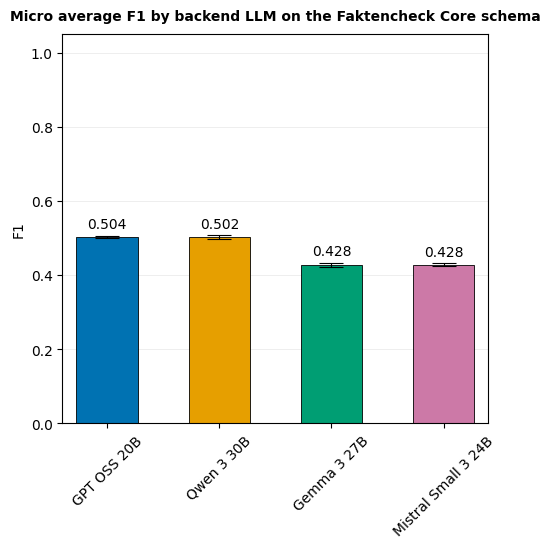

Saved ALL.precision plot to: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm/notebooks/plots/all_precision.png
Saved ALL.precision plot to: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm/notebooks/plots/all_precision.pdf


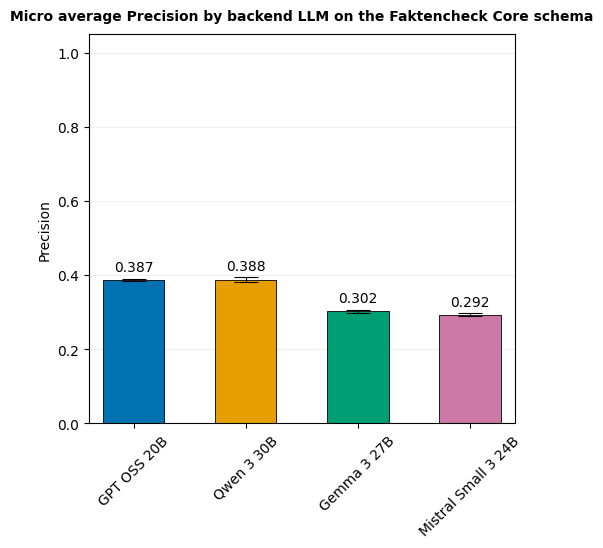

Saved ALL.recall plot to: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm/notebooks/plots/all_recall.png
Saved ALL.recall plot to: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm/notebooks/plots/all_recall.pdf


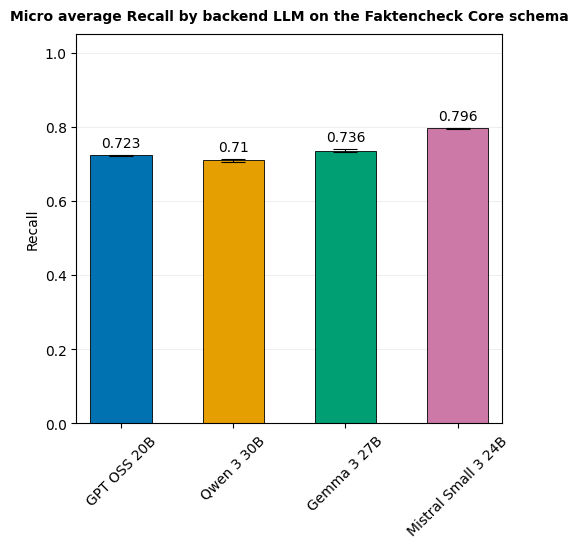

Saved ALL.support plot to: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm/notebooks/plots/all_support.png
Saved ALL.support plot to: /home/leonhard/Dokumente/code/dfki/kiba-d/kibad-llm/notebooks/plots/all_support.pdf


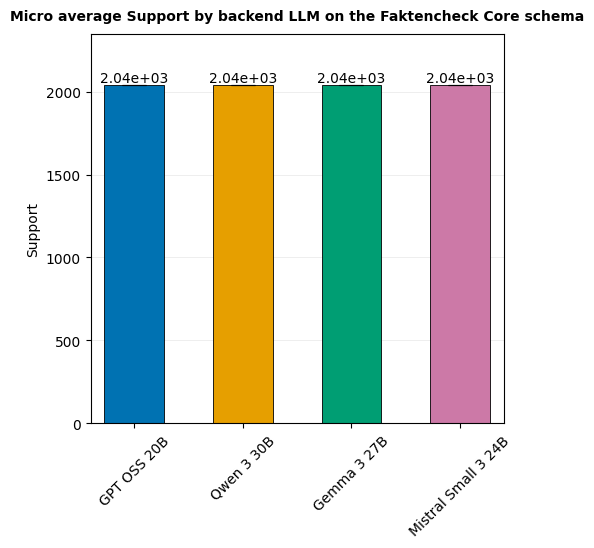

In [8]:
# %% [markdown]
# ## Generate one plot per variable and metric


# %%
created_figures = {}

for metric in metrics:
    for variable in variables:
        # Some variables might not exist for every metric.
        if variable not in stats[metric]:
            continue

        filename_base = f"{safe_filename(variable)}_{safe_filename(metric)}"

        output_paths = [OUTPUT_DIR / f"{filename_base}.{ext}" for ext in OUTPUT_FORMATS]

        fig, ax = plot_variable_metric(
            metric=metric,
            variable=variable,
            output_paths=output_paths,
        )

        created_figures[(metric, variable)] = (fig, ax)

In [ ]:
# %% [markdown]
# # Compare two experiments across variables and metrics
#
# This notebook loads two JSON files with the same structure.
#
# Metric labels are expected to look like:
#
# - `ALL.f1`
# - `ALL.precision`
# - `habitat.f1`
# - `ecosystem_type.category.recall`
#
# The last suffix is interpreted as the metric.
# Everything before the last dot is interpreted as the variable.
#
# For each variable-metric pair, the notebook creates one grouped bar chart:
#
# - x-axis: backend LLMs
# - bars within each model group: Experiment 1 vs Experiment 2
# - colors: light/dark variants of each model's base color

import json

# %%
from pathlib import Path
import re

import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np

# Optional IEEE/science style
try:
    import scienceplots  # noqa: F401

    plt.style.use(["science", "ieee", "no-latex"])
except Exception:
    print("scienceplots not available; using current matplotlib style.")

In [ ]:
# %% [markdown]
# ## Configuration

# %%
EXPERIMENTS = [
    {
        "name": "Faktencheck Core dev set",
        "path": Path(
            "../data/prediction_results/logs/525_faktencheck_core_bestconfig_testset/figure_data/faktencheck_core_f1_micro_flat-ALL-data.json"
        ),
    },
    {
        "name": "Faktencheck Core test set",
        "path": Path(
            "../data/prediction_results/logs/525_faktencheck_core_bestconfig_testset/figure_data/faktencheck_core_f1_micro_flat-ALL-data.json"
        ),
    },
]

OUTPUT_DIR = Path("plots_two_experiments")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FORMATS = ["png", "pdf"]

# If None, all metrics found in both files are plotted.
# Otherwise, use e.g. ["f1", "precision", "recall"].
METRICS_TO_INCLUDE = None
# METRICS_TO_INCLUDE = ["f1", "precision", "recall"]

# If None, all variables found in both files are plotted.
# Otherwise, use e.g. ["ALL", "AVG", "habitat"].
VARIABLES_TO_INCLUDE = None
# VARIABLES_TO_INCLUDE = ["ALL", "AVG", "biodiversity_level", "habitat"]

# Error bars:
# "std" = standard deviation
# "sem" = standard error of the mean
ERRORBAR = "std"

# IEEE single-column figure size
IEEE_ONE_COLUMN_WIDTH_IN = 7  # 3.5
FIG_HEIGHT_IN = 5.6  # 2.8

# Total width occupied by the experiment bars inside each model group.
GROUP_WIDTH = 0.62

# Sort model groups by this reference experiment, variable, and metric.
# Set SORT_BY = None to keep JSON order.
SORT_BY = {
    "experiment": EXPERIMENTS[0]["name"],
    "variable": "ALL",
    "metric": "f1",
}

# If True, every plot is sorted by its own values from Experiment 1.
# If False, all plots use the same model order from SORT_BY.
SORT_EACH_PLOT_INDIVIDUALLY = False

PRETTY_METRIC = {
    "f1": "F1",
    "precision": "Precision",
    "recall": "Recall",
    "support": "Support",
}

PRETTY_LLM = {
    "gpt_oss_20b": "GPT OSS 20B",
    "mistral_small_3_24b": "Mistral Small 3 24B",
    "gemma3_27b": "Gemma 3 27B",
    "qwen3_30b": "Qwen 3 30B",
    "gpt_5": "GPT-5",
}

PRETTY_VARIABLE = {
    "ALL": "Micro average",
    "AVG": "Macro average",
    "biodiversity_level": "Biodiversity level",
    "ecosystem_type.category": "Ecosystem type - category",
    "ecosystem_type.term": "Ecosystem type - term",
    "habitat": "Habitat",
    "taxa.species_group": "Taxa - species group",
}

In [ ]:
# %% [markdown]
# ## Helper functions


# %%
def clean_category_label(category: str) -> str:
    """
    Convert e.g.
    prediction.extractor/llm=gpt_oss_20b_in_process
    to
    GPT OSS 20B
    """
    match = re.search(r"llm=([^/]+)", category)
    label = match.group(1) if match else category

    if label.endswith("_in_process"):
        label = label[: -len("_in_process")]

    return PRETTY_LLM.get(label, label.replace("_", " ").title())


def short_model_label(label: str) -> str:
    """
    Shorten labels for IEEE single-column plots.
    """
    replacements = {
        "GPT OSS 20B": "GPT OSS\n20B",
        "Mistral Small 3 24B": "Mistral\nSmall 3",
        "Gemma 3 27B": "Gemma 3\n27B",
        "Qwen 3 30B": "Qwen 3\n30B",
        "GPT-5": "GPT-5",
    }
    return replacements.get(label, label)


def pretty_variable_name(variable: str) -> str:
    return PRETTY_VARIABLE.get(variable, variable.replace("_", " "))


def pretty_metric_name(metric: str) -> str:
    return PRETTY_METRIC.get(metric, metric.replace("_", " ").title())


def safe_filename(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9._-]+", "_", text)
    text = text.replace(".", "_")
    return text


def split_metric_label(metric_label: str):
    """
    Split metric labels of the form:

        variable.metric

    where variable may contain dots.

    Examples
    --------
    ALL.f1 -> variable='ALL', metric='f1'
    habitat.precision -> variable='habitat', metric='precision'
    ecosystem_type.category.f1 -> variable='ecosystem_type.category', metric='f1'
    """
    if "." not in metric_label:
        raise ValueError(
            f"Expected metric label of form '<variable>.<metric>', got: {metric_label}"
        )

    variable, metric = metric_label.rsplit(".", 1)
    return variable, metric


def mean_and_error(samples, errorbar: str = "std"):
    samples = np.asarray(samples, dtype=float)

    if len(samples) == 0:
        raise ValueError("Found a point with an empty `samples` list.")

    mean = float(np.mean(samples))

    # Single-run experiments, e.g. GPT-5: no error bar.
    if len(samples) == 1:
        return mean, 0.0, 1

    std = float(np.std(samples, ddof=1))

    if errorbar == "std":
        err = std
    elif errorbar == "sem":
        err = std / np.sqrt(len(samples))
    else:
        raise ValueError(f"Unknown errorbar type: {errorbar}")

    return mean, err, len(samples)


def blend_with(color, target_color, amount: float):
    """
    Blend a color with another target color.

    amount=0 gives original color.
    amount=1 gives target color.
    """
    color = np.array(mcolors.to_rgb(color))
    target = np.array(mcolors.to_rgb(target_color))
    return tuple((1 - amount) * color + amount * target)


def lighten_color(color, amount: float = 0.45):
    return blend_with(color, "white", amount)


def darken_color(color, amount: float = 0.20):
    return blend_with(color, "black", amount)

In [ ]:
# %% [markdown]
# ## Load one experiment file


# %%
def load_experiment_file(
    json_path: Path,
    metrics_to_include=None,
    variables_to_include=None,
    errorbar: str = "std",
):
    """
    Load one JSON file.

    Returns
    -------
    categories:
        Model/category order from the first matching plot.

    stats:
        stats[metric][variable][category] = {
            "mean": ...,
            "err": ...,
            "n": ...,
            "samples": ...
        }

    pair_order:
        Order of `(metric, variable)` pairs as encountered in the JSON.
    """
    with json_path.open("r", encoding="utf-8") as f:
        obj = json.load(f)

    stats = {}
    pair_order = []

    categories = None

    for plot in obj["plots"]:
        metric_label = plot["metadata"]["metric_label"]
        variable, metric = split_metric_label(metric_label)

        if metrics_to_include is not None and metric not in metrics_to_include:
            continue

        if variables_to_include is not None and variable not in variables_to_include:
            continue

        if categories is None:
            categories = [point["category"] for point in plot["data"]["points"]]

        stats.setdefault(metric, {})
        stats[metric].setdefault(variable, {})

        pair = (metric, variable)
        if pair not in pair_order:
            pair_order.append(pair)

        for point in plot["data"]["points"]:
            category = point["category"]
            samples = point["samples"]

            mean, err, n = mean_and_error(samples, errorbar=errorbar)

            stats[metric][variable][category] = {
                "mean": mean,
                "err": err,
                "n": n,
                "samples": samples,
            }

    if categories is None:
        raise ValueError(f"No matching plots found in {json_path}")

    return categories, stats, pair_order

In [ ]:
# %% [markdown]
# ## Load both experiments


# %%
experiment_stats = {}
experiment_categories = {}
experiment_pair_orders = {}

for exp in EXPERIMENTS:
    name = exp["name"]
    path = exp["path"]

    cats, st, pair_order = load_experiment_file(
        path,
        metrics_to_include=METRICS_TO_INCLUDE,
        variables_to_include=VARIABLES_TO_INCLUDE,
        errorbar=ERRORBAR,
    )

    experiment_categories[name] = cats
    experiment_stats[name] = st
    experiment_pair_orders[name] = pair_order

# Use first experiment as reference for model order.
reference_experiment = EXPERIMENTS[0]["name"]
categories = list(experiment_categories[reference_experiment])

# Check that all experiments contain the same model categories.
reference_category_set = set(categories)

for exp in EXPERIMENTS[1:]:
    name = exp["name"]
    category_set = set(experiment_categories[name])

    if category_set != reference_category_set:
        missing = reference_category_set - category_set
        extra = category_set - reference_category_set
        raise ValueError(
            f"Model categories differ for {name}.\n"
            f"Missing from {name}: {missing}\n"
            f"Extra in {name}: {extra}"
        )

# Use only metric-variable pairs present in all experiments.
pair_sets = []

for exp in EXPERIMENTS:
    name = exp["name"]
    pairs = {
        (metric, variable)
        for metric in experiment_stats[name]
        for variable in experiment_stats[name][metric]
    }
    pair_sets.append(pairs)

common_pairs = set.intersection(*pair_sets)

# Preserve order from first experiment.
ordered_pairs = [
    pair for pair in experiment_pair_orders[reference_experiment] if pair in common_pairs
]

if not ordered_pairs:
    raise ValueError("No common metric-variable pairs found across experiments.")

metrics = list(dict.fromkeys(metric for metric, variable in ordered_pairs))
variables = list(dict.fromkeys(variable for metric, variable in ordered_pairs))

print("Common metric-variable pairs:")
for metric, variable in ordered_pairs:
    print(f"  {variable}.{metric}")

print("\nModels:")
for category in categories:
    print(f"  {clean_category_label(category)}")

In [ ]:
# %% [markdown]
# ## Sort models

# %%
if SORT_BY is not None:
    sort_experiment = SORT_BY["experiment"]
    sort_variable = SORT_BY["variable"]
    sort_metric = SORT_BY["metric"]

    if sort_experiment not in experiment_stats:
        raise ValueError(
            f"Sort experiment {sort_experiment!r} not found. "
            f"Available: {list(experiment_stats.keys())}"
        )

    if sort_metric not in experiment_stats[sort_experiment]:
        raise ValueError(f"Sort metric {sort_metric!r} not found in {sort_experiment!r}.")

    if sort_variable not in experiment_stats[sort_experiment][sort_metric]:
        raise ValueError(
            f"Sort variable {sort_variable!r} not found for "
            f"{sort_experiment!r}.{sort_metric!r}."
        )

    categories = sorted(
        categories,
        key=lambda category: experiment_stats[sort_experiment][sort_metric][sort_variable][
            category
        ]["mean"],
        reverse=True,
    )

labels = [clean_category_label(c) for c in categories]
plot_labels = [short_model_label(label) for label in labels]

print("Model order:")
for category, label in zip(categories, labels):
    if SORT_BY is not None:
        value = experiment_stats[sort_experiment][sort_metric][sort_variable][category]["mean"]
        print(f"  {label}: {value:.4f} ({sort_experiment}, {sort_variable}.{sort_metric})")
    else:
        print(f"  {label}")

In [ ]:
# %% [markdown]
# ## Color scheme
#
# Each model has a base color.
#
# - Experiment 1 uses a light version of that model color.
# - Experiment 2 uses a dark version of that model color.

# %%
MODEL_COLORS = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # purple
    "#D55E00",  # vermillion
    "#56B4E9",  # sky blue
    "#F0E442",  # yellow
]

model_base_colors = {
    category: MODEL_COLORS[i % len(MODEL_COLORS)] for i, category in enumerate(categories)
}


def color_for_experiment(category, exp_index: int):
    """
    Light/dark shade of the model's base color.

    For two experiments:
    - exp_index 0: light color
    - exp_index 1: dark color
    """
    base = model_base_colors[category]

    if exp_index == 0:
        return lighten_color(base, amount=0.45)
    elif exp_index == 1:
        return darken_color(base, amount=0.15)
    else:
        # Fallback if later expanded beyond two experiments.
        return base

In [ ]:
# %% [markdown]
# ## Plot function for grouped experiment bars


# %%
def plot_variable_metric_grouped(metric: str, variable: str, output_paths):
    """
    Create and save one grouped bar chart for a variable-metric pair.

    For each model, the bars are grouped by experiment.
    """
    exp_names = [exp["name"] for exp in EXPERIMENTS]
    n_experiments = len(exp_names)

    if n_experiments != 2:
        print(
            "Warning: this color scheme is designed for two experiments. "
            "Additional experiments will use the base model color."
        )

    for exp_name in exp_names:
        if metric not in experiment_stats[exp_name]:
            raise ValueError(f"Metric {metric!r} missing in {exp_name!r}")

        if variable not in experiment_stats[exp_name][metric]:
            raise ValueError(
                f"Variable {variable!r} missing for metric {metric!r} " f"in {exp_name!r}"
            )

    if SORT_EACH_PLOT_INDIVIDUALLY:
        # Sort by Experiment 1's values for this particular plot.
        sort_exp_name = exp_names[0]

        plot_categories = sorted(
            categories,
            key=lambda category: experiment_stats[sort_exp_name][metric][variable][category][
                "mean"
            ],
            reverse=True,
        )
    else:
        plot_categories = list(categories)

    x = np.arange(len(plot_categories))

    single_bar_width = GROUP_WIDTH / n_experiments
    offsets = (np.arange(n_experiments) - (n_experiments - 1) / 2) * single_bar_width

    fig, ax = plt.subplots(figsize=(IEEE_ONE_COLUMN_WIDTH_IN, FIG_HEIGHT_IN))

    all_ymax_candidates = []

    for exp_index, exp_name in enumerate(exp_names):
        means = np.array(
            [
                experiment_stats[exp_name][metric][variable][category]["mean"]
                for category in plot_categories
            ]
        )

        errs = np.array(
            [
                experiment_stats[exp_name][metric][variable][category]["err"]
                for category in plot_categories
            ]
        )

        ns = np.array(
            [
                experiment_stats[exp_name][metric][variable][category]["n"]
                for category in plot_categories
            ]
        )

        bar_positions = x + offsets[exp_index]

        colors = [color_for_experiment(category, exp_index) for category in plot_categories]

        bars = ax.bar(
            bar_positions,
            means,
            width=single_bar_width * 0.90,
            color=colors,
            edgecolor="black",
            linewidth=0.45,
            label=exp_name,
        )

        # Error bars only for multi-run experiments/models.
        for xi, yi, err, n in zip(bar_positions, means, errs, ns):
            if n > 1:
                ax.errorbar(
                    xi,
                    yi,
                    yerr=err,
                    fmt="none",
                    ecolor="black",
                    elinewidth=0.65,
                    capsize=4.0,
                    capthick=0.65,
                )

        # Print scores on top of all bars with 3 significant digits.
        for bar, val, err, n in zip(bars, means, errs, ns):
            y = val + (err if n > 1 else 0.0) + 0.010
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                y * 1.03,
                f"{val:.3g}",
                ha="center",
                va="bottom",
                fontsize=10,
                rotation=90,
            )

        all_ymax_candidates.extend(means + np.where(ns > 1, errs, 0.0))

    title = f"{pretty_variable_name(variable)} {pretty_metric_name(metric)}"

    ax.set_title(
        title,
        fontsize=12,
        # fontweight="bold",
        pad=10,
    )

    ax.set_ylabel(pretty_metric_name(metric), fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            clean_category_label(category)  # short_model_label(clean_category_label(category))
            for category in plot_categories
        ],
        rotation=45,
        ha="center",
        fontsize=10,
    )

    ax.tick_params(axis="y", labelsize=10)

    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)

    max_y = float(np.max(all_ymax_candidates))

    ax.set_xlim(-0.4, len(experiments) - 0.6)
    if metric.lower() == "support":
        ax.set_ylim(0, max_y * 1.55)
    else:
        ax.set_ylim(0, 1.05)  # min(1.05, max_y + 0.13))
        # ax.set_ylim(0, min(1.05, max_y + 0.13))

    # Legend explaining light/dark experiment grouping.
    legend_handles = [
        Patch(
            facecolor="0.80",
            edgecolor="black",
            linewidth=0.5,
            label=f"{exp_names[0]}: light shade",
        ),
        Patch(
            facecolor="0.35",
            edgecolor="black",
            linewidth=0.5,
            label=f"{exp_names[1]}: dark shade",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        fontsize=10,
        frameon=True,
        loc="upper right",
    )

    fig.tight_layout(pad=0.35)

    for output_path in output_paths:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)

        fig.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )

        print(f"Saved {variable}.{metric} grouped plot to: " f"{output_path.resolve()}")

    plt.show()

    return fig, ax

In [ ]:
# %% [markdown]
# ## Generate one grouped plot per variable-metric pair


# %%
created_figures = {}

for metric, variable in ordered_pairs:
    filename_base = f"{safe_filename(variable)}_{safe_filename(metric)}_grouped_experiments"

    output_paths = [OUTPUT_DIR / f"{filename_base}.{ext}" for ext in OUTPUT_FORMATS]

    fig, ax = plot_variable_metric_grouped(
        metric=metric,
        variable=variable,
        output_paths=output_paths,
    )

    created_figures[(metric, variable)] = (fig, ax)